In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

In [4]:
data = pd.read_csv("AirPassengers.csv")
# data.head()

<ipython-input-47-045071e851c3>:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


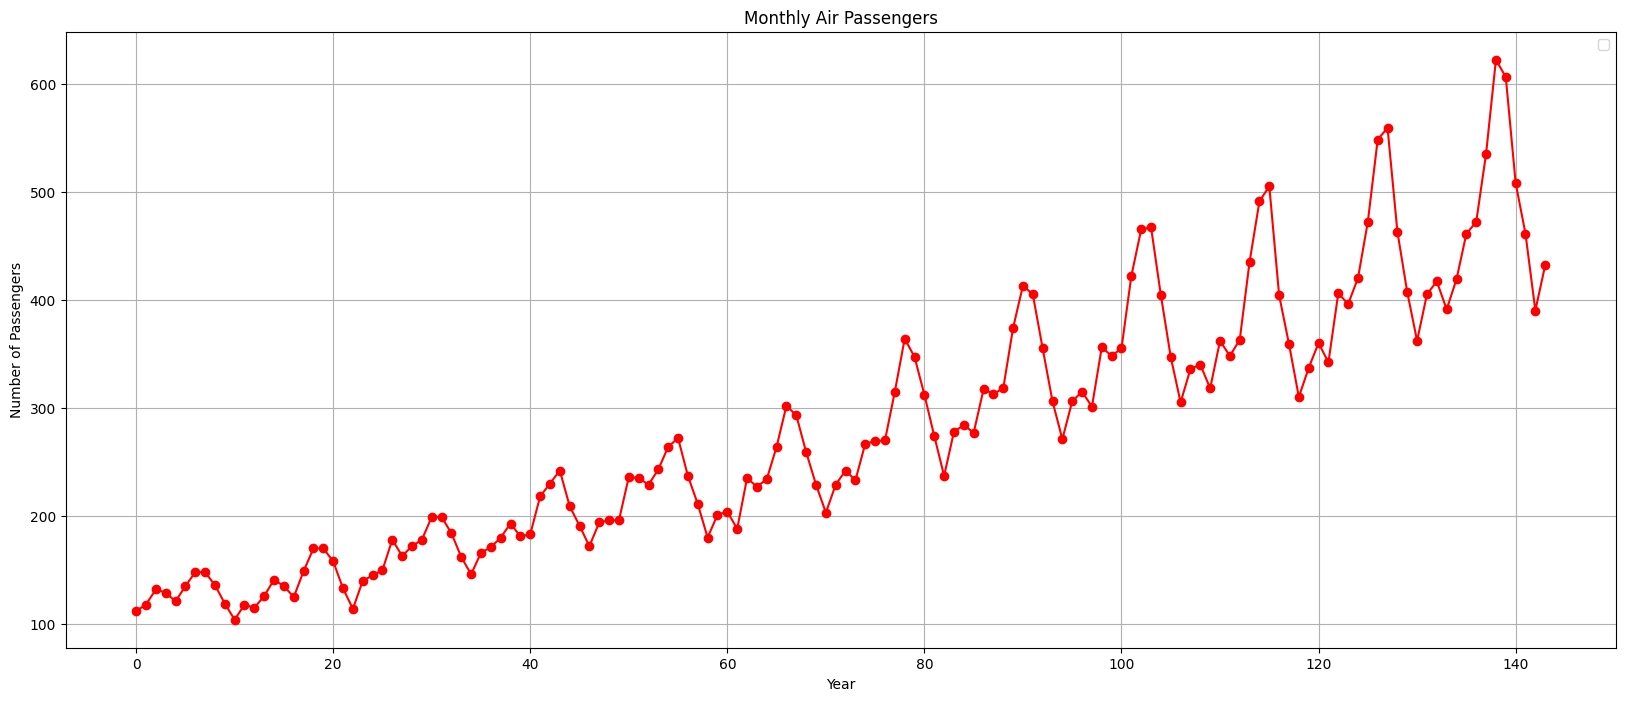

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot(data.index, data['Passengers'], marker='o', linestyle='-', color='r')
plt.title('Monthly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Rolling statistics (window = 12 months)
rolling_mean = data['Passengers'].rolling(window=12).mean()
rolling_std = data['Passengers'].rolling(window=12).std()

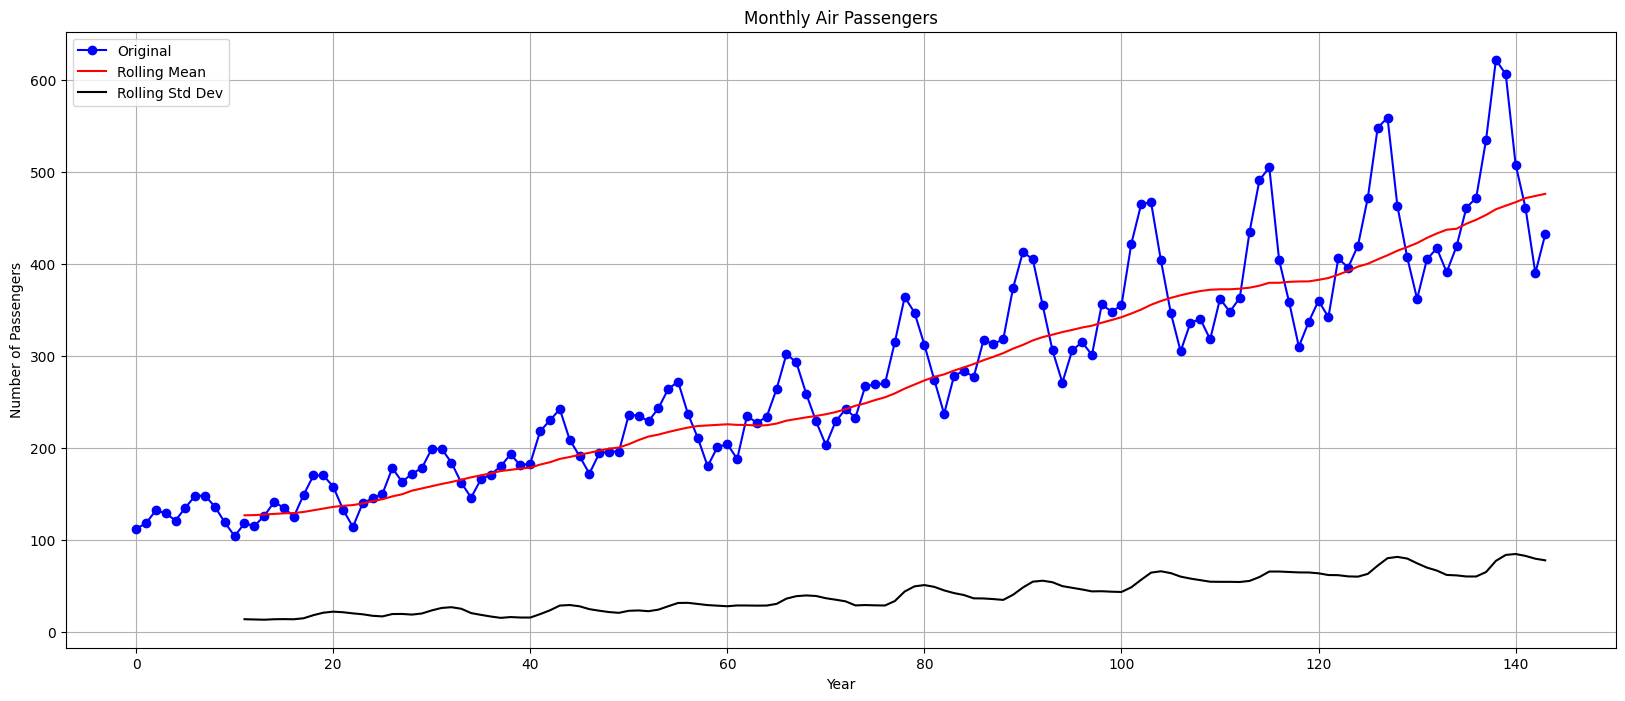

In [ ]:
plt.figure(figsize=(20, 8))
plt.plot( data['Passengers'], marker='o', linestyle='-', color='blue', label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std Dev')
plt.title('Monthly Air Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test on original data
# adf_result = adfuller(data['Passengers'], maxlag=13, autolog=None)
# IN here we can set custom value to leg and "autolog=None" say "Don't compare anything! Just use lag = 5 only"
adf_result = adfuller(data['Passengers'])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("No. of lags used:", adf_result[2])
print("No. of observations used:", adf_result[3])
print("Critical Values:", adf_result[4])
print("IC Best:", adf_result[5])


for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
No. of lags used: 13
No. of observations used: 130
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
IC Best: 996.692930839019
Critical Value (1%): -3.482
Critical Value (5%): -2.884
Critical Value (10%): -2.579


<Figure size 1000x500 with 0 Axes>

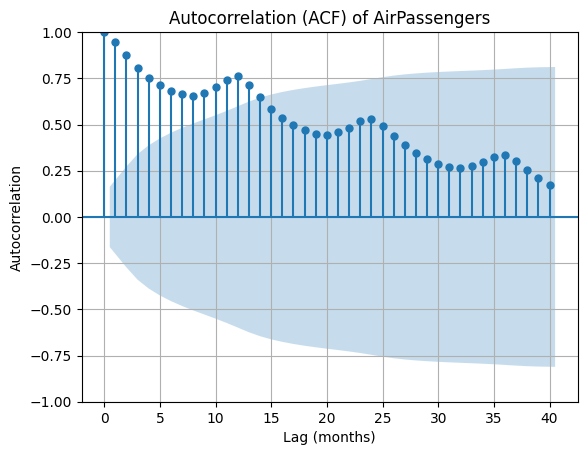

In [ ]:
# Extract the passenger column
passengers = data['Passengers']

# Plot the autocorrelation
plt.figure(figsize=(10, 5))
plot_acf(passengers, lags=40)  # Try up to 40 lags (months)
plt.title("Autocorrelation (ACF) of AirPassengers")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

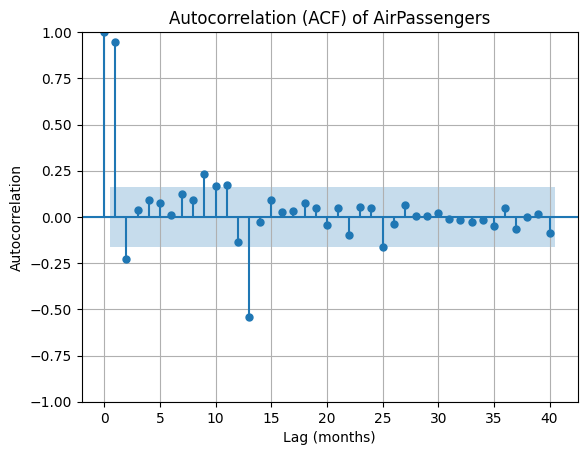

In [ ]:
# Plot the autocorrelation
plt.figure(figsize=(10, 5))
plot_pacf(passengers, lags=40)  # Try up to 40 lags (months)
plt.title("Autocorrelation (ACF) of AirPassengers")
plt.xlabel("Lag (months)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

<Figure size 1200x800 with 0 Axes>

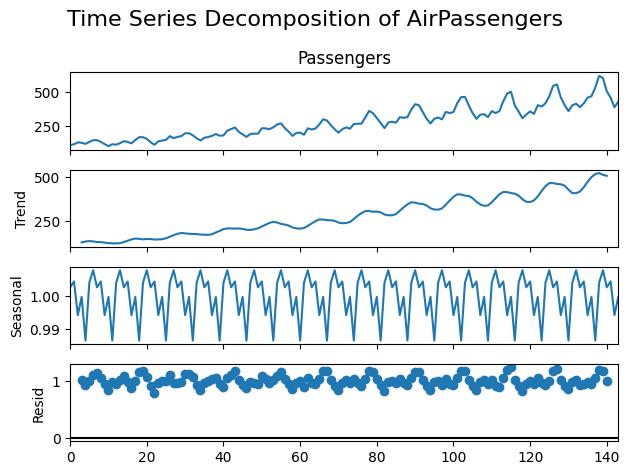

In [ ]:
# Run decomposition (assume monthly data → period=12)
decomposition = seasonal_decompose(data['Passengers'], model='multiplicative', period=7)
# decomposition = seasonal_decompose(data['Passengers'], model='additive', period=12)

# Plot the components
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle('Time Series Decomposition of AirPassengers', fontsize=16)
plt.tight_layout()
plt.show()

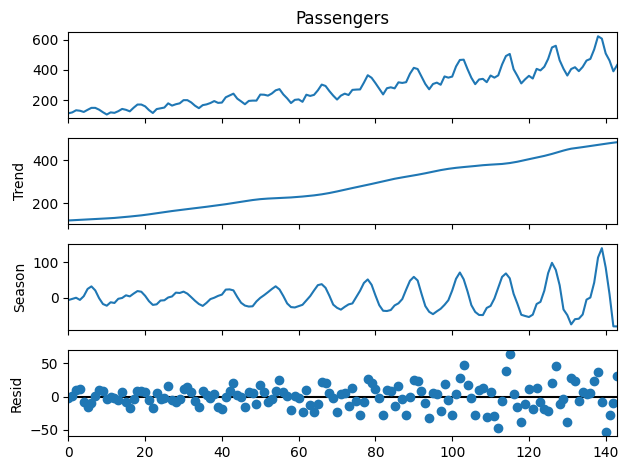

In [ ]:
stl = STL(data['Passengers'], period=13)  # Use an odd number for the seasonal component
# stl = STL(passengers, seasonal=12)
result = stl.fit()
result.plot()
plt.show()

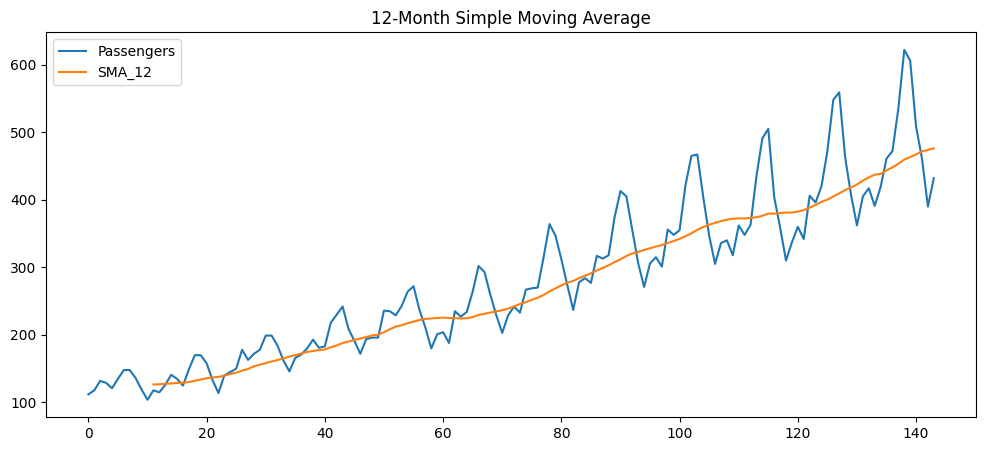

In [5]:
# Calculate 12-month SMA (to smooth yearly seasonality)
data['SMA_12'] = data['Passengers'].rolling(window=12).mean()

# Plot
data[['Passengers', 'SMA_12']].plot(figsize=(12, 5)),
plt.title("12-Month Simple Moving Average")
plt.show()

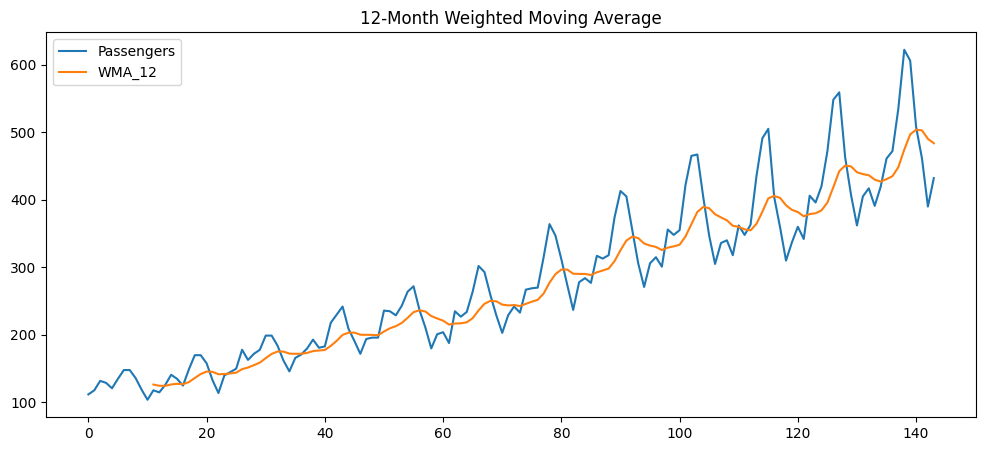

In [7]:
# Define weights (linear decay: recent months get higher weight)
weights = np.arange(1, 13)  # [1, 2, ..., 12] for 12-month window
data['WMA_12'] = data['Passengers'].rolling(window=12).apply(lambda x: np.sum(x * weights) / np.sum(weights))

# Plot
data[['Passengers', 'WMA_12']].plot(figsize=(12, 5))
plt.title("12-Month Weighted Moving Average")
plt.show()

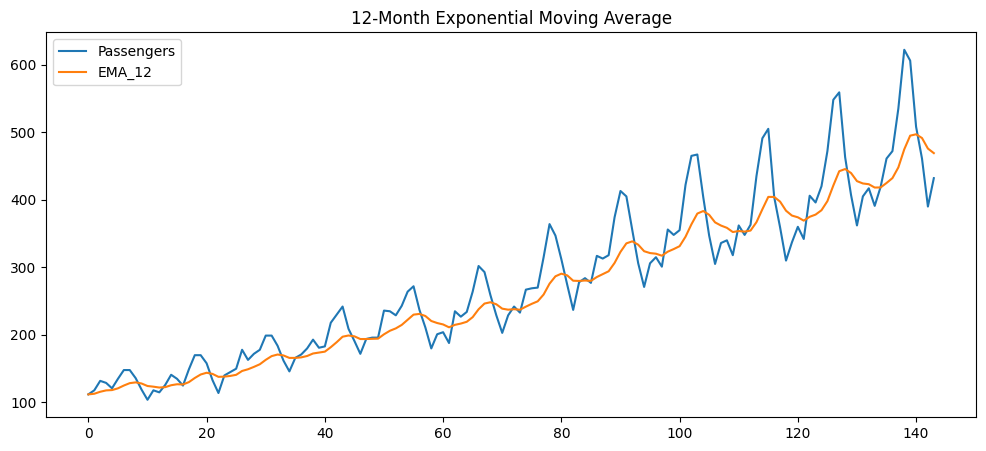

In [8]:
# Calculate 12-month EMA (alpha = 2/(12+1) ≈ 0.15)
data['EMA_12'] = data['Passengers'].ewm(span=12, adjust=False).mean()

# Plot
data[['Passengers', 'EMA_12']].plot(figsize=(12, 5))
plt.title("12-Month Exponential Moving Average")
plt.show()